In [1]:
from PIL import Image
from math import sqrt

2. Реализовать модифицированный метод Брезенхема, Сяолиня Ву и Гупта-Спрулла для устранения ступенчатости
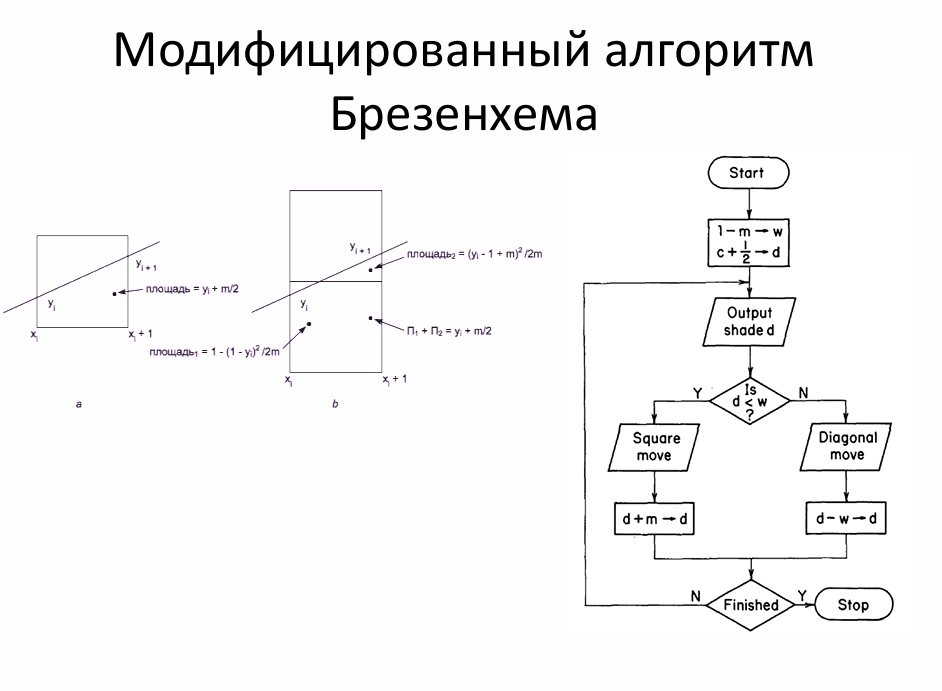

In [2]:
def Mod_Brezenheim(img, x0, y0, x1, y1):
    b = 20
    pixels = img.load()
    steep = abs(y1 - y0) > abs(x1 - x0)
    if steep: x0, y0, x1, y1 = y0, x0, y1, x1
    if x0 > x1: x0, y0, x1, y1 = x1, y1, x0, y0
    dx = x1 - x0
    dy = abs(y1 - y0)
    step_y = 1 if y1 > y0 else -1
    m = dy / dx
    w = 1 - m
    d = 0.5
    y = y0
    for x in range(x0, x1 + 1):
        px1, py1 = (y , x) if steep else (x, y)
        px2, py2 = (y + step_y, x) if steep else (x, y + step_y)
        pixels[b + px1, b - py1] = int(255 * d)
        pixels[b + px2, b - py2] = int(255 * (1 - d))
        if d > w:
            d = d + m - 1
            y += step_y
        else:
            d +=m

In [3]:
img = Image.new("L", (41, 41), color=255)
Mod_Brezenheim(img, -20, 0, 20, -5)
img.show()
img.save("output1.jpg")

Алгоритм Сяолиня Ву

In [4]:
def XiaolinWu(img, x0, y0, x1, y1):
    b = 20
    pixels = img.load()
    steep = abs(y1 - y0) > abs(x1 - x0)
    if steep: x0, y0, x1, y1 = y0, x0, y1, x1
    if x0 > x1: x0, y0, x1, y1 = x1, y1, x0, y0
    dx = x1 - x0
    dy = y1 - y0
    step_y = 1 if y0 < y1 else -1
    gradient = dy / dx
    y = y0
    for x in range(x0, x1 + 1):
        px1, py1 = (int(y), x) if steep else (x, int(y))
        px2, py2 = (int(y) + step_y, x) if steep else (x, int(y) + step_y)
        pixels[b + px1, b - py1] = int(255 * abs(y - int(y)))
        pixels[b + px2, b - py2] = int(255 * (1 - abs(y - int(y))))
        y += gradient

In [5]:
img = Image.new("L", (41, 41), color=255)
XiaolinWu(img, -20, 0, 20, -5)
img.show()
img.save("output2.jpg")

Алгоритм Гупта-спрулла

In [6]:
def Gupta_Sprull(img, x0, y0, x1, y1):
    b = 20
    pixels = img.load()
    A = y0 - y1
    B = x1 - x0
    C = x0 * y1 - x1 * y0
    len_line = sqrt(A**2 + B**2)
    steep = abs(y1 - y0) > abs(x1 - x0)
    if steep: x0, y0, x1, y1 = y0, x0, y1, x1
    if x0 > x1: x0, y0, x1, y1 = x1, y1, x0, y0
    dx = x1 - x0
    dy = abs(y1 - y0)
    d = 2 * dy - dx
    y = y0
    step_y = 1 if y1 > y0 else -1
    for x in range(x0, x1 + 1):
        for i in range(-1, 2):
            for j in range(-1, 2):
                px = x + i
                py = y + j
                curr_x, curr_y = (py, px) if steep else (px, py)
                dist = (A * curr_x + B * curr_y + C) / len_line
                if abs(dist) < 1:
                    weight = (1 - abs(dist))**2
                    if 0 <= b + curr_x < 40 and 0 <= b - curr_y < 40:
                        pixels[b + curr_x, b - curr_y] = int(255 * (1 - weight))
        if d > 0:
            y += step_y
            d -= 2 * dx
        d += 2 * dy

In [7]:
img = Image.new("L", (41, 41), color=255)
Gupta_Sprull(img, 0,  -20, -5, 20,)
img.show()
img.save("output3.jpg")